# Proyecto 2 - Modelo predictivo Saber 11 Atlántico

**Estudiante:** Maria Paula Ospina (202123208)  
**Rol:** Ciencia de datos y Despliegue
**Usuario final:** Secretaría de Educación del Atlántico  

## Pregunta de negocio

**¿En qué medida las condiciones socioeconómicas, el acceso a recursos tecnológicos en el hogar y ciertas características institucionales permiten predecir el puntaje global de los estudiantes del departamento del Atlántico en las pruebas Saber 11?**

Este notebook desarrolla un modelo basado en redes neuronales para predecir el puntaje global de los estudiantes del Atlántico

## Transformación y Limpieza según la pregunta planteada

In [1]:
#Cargar csv limpio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../Tarea 2 - Limpieza_Datos/saber11_limpio.csv")

print(data.shape)
data.head()

(210695, 129)


,periodo,estu_tipodocumento,estu_consecutivo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_mcpio_ubicacion,...,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
0,20194,CC,SB11201940603865,3.080010e+11,308001008441,8,8001,107227.0,ATLANTICO,BARRANQUILLA,...,0,0,0,0,1,0,0,0,1,0
1,20194,CC,SB11201940603865,3.080010e+11,308001008441,8,8001,107227.0,ATLANTICO,BARRANQUILLA,...,0,0,0,0,1,0,0,0,1,0
2,20142,TI,SB11201420562024,1.086380e+11,108638000982,8,8638,116822.0,ATLANTICO,SABANALARGA,...,0,0,0,0,1,0,0,0,1,0
3,20162,TI,SB11201620074389,1.087580e+11,108758000066,8,8758,110072.0,ATLANTICO,SOLEDAD,...,0,0,1,0,1,0,0,0,1,0
4,20142,TI,SB11201420200133,1.080010e+11,108001003114,8,8001,82636.0,ATLANTICO,BARRANQUILLA,...,0,0,0,0,1,0,0,0,1,0


In [2]:
data.columns.tolist()

['periodo',
 'estu_tipodocumento',
 'estu_consecutivo',
 'cole_cod_dane_establecimiento',
 'cole_cod_dane_sede',
 'cole_cod_depto_ubicacion',
 'cole_cod_mcpio_ubicacion',
 'cole_codigo_icfes',
 'cole_depto_ubicacion',
 'cole_mcpio_ubicacion',
 'cole_nombre_establecimiento',
 'cole_nombre_sede',
 'cole_sede_principal',
 'estu_cod_depto_presentacion',
 'estu_cod_mcpio_presentacion',
 'estu_cod_reside_depto',
 'estu_cod_reside_mcpio',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_estudiante',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_tienecomputador',
 'fami_tieneinternet',
 'desemp_ingles',
 'punt_ingles',
 'punt_matematicas',
 'punt_sociales_ciudadanas',
 'punt_c_naturales',
 'punt_lectura_critica',
 'punt_global',
 'cole_naturaleza_no oficial',
 'cole_naturaleza_oficial',
 'cole_bilingue_n',
 'cole_bilingue_s',
 'cole_jorna

In [3]:
data.describe()

,periodo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,...,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
count,210695.000000,2.106950e+05,2.106950e+05,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.0,210695.000000,...,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000
mean,20182.860082,1.765473e+11,1.764552e+11,8.041268,8310.522101,226645.874335,8.057467,8279.884701,8.0,8267.028971,...,0.001220,0.026156,0.409435,0.043627,0.781134,0.192069,0.026797,0.211552,0.763212,0.025236
std,28.660215,9.495093e+10,9.492038e+10,1.474381,1504.079579,263355.385177,1.577531,1606.091500,0.0,326.811915,...,0.034904,0.159600,0.491731,0.204264,0.413479,0.393928,0.161490,0.408410,0.425112,0.156840
min,20142.000000,1.050010e+11,1.050010e+11,5.000000,5001.000000,2956.000000,5.000000,5001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20162.000000,1.080010e+11,1.080010e+11,8.000000,8001.000000,47068.000000,8.000000,8001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,20181.000000,1.086380e+11,1.086380e+11,8.000000,8001.000000,104471.000000,8.000000,8001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,20194.000000,3.080010e+11,3.080010e+11,8.000000,8638.000000,211565.000000,8.000000,8638.000000,8.0,8638.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,20224.000000,4.251750e+11,4.251750e+11,85.000000,85001.000000,806489.000000,95.000000,95025.000000,8.0,8849.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Algunas variables numéricas corresponden a códigos administrativos o identificadores de colegios, sedes o municipios. Aunque aparecen como variables numéricas en el resumen descriptivo, no representan magnitudes continuas y no serán utilizadas directamente como predictores del modelo. Su uso podría introducir relaciones artificiales o poco interpretables.

#Eliminación columnas de codigos

In [4]:
columnas_eliminar = [
    # Identificadores del estudiante
    "estu_tipodocumento",
    "estu_consecutivo",
    "estu_estudiante",

    # Identificadores/códigos del colegio o sede
    "cole_cod_dane_establecimiento",
    "cole_cod_dane_sede",
    "cole_codigo_icfes",
    "cole_nombre_establecimiento",
    "cole_nombre_sede",

    # Códigos administrativos de ubicación
    "cole_cod_depto_ubicacion",
    "cole_cod_mcpio_ubicacion",
    "estu_cod_depto_presentacion",
    "estu_cod_mcpio_presentacion",
    "estu_cod_reside_depto",
    "estu_cod_reside_mcpio"
]

df = data.drop(columns=columnas_eliminar)

Se van a eliminar los puntajes especificos de cada area, dado que hacen parte del resultado de puntaje global

In [5]:
columnas_eliminar = [
    "punt_ingles",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_lectura_critica",
    "desemp_ingles"
]

df = df.drop(columns=columnas_eliminar)

In [6]:
df.columns.tolist()

['periodo',
 'cole_depto_ubicacion',
 'cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_tienecomputador',
 'fami_tieneinternet',
 'punt_global',
 'cole_naturaleza_no oficial',
 'cole_naturaleza_oficial',
 'cole_bilingue_n',
 'cole_bilingue_s',
 'cole_jornada_completa',
 'cole_jornada_mañana',
 'cole_jornada_noche',
 'cole_jornada_sabatina',
 'cole_jornada_tarde',
 'cole_jornada_unica',
 'cole_calendario_a',
 'cole_calendario_b',
 'cole_calendario_otro',
 'cole_area_ubicacion_rural',
 'cole_area_ubicacion_urbano',
 'cole_caracter_académico',
 'cole_caracter_no aplica',
 'cole_caracter_técnico',
 'cole_caracter_técnico/académico',
 'cole_genero_femenino',
 'cole_genero_masculino',
 'cole_genero_mixto',
 'fami_estratovivienda_estrato 1',
 'fami_estr

In [7]:
#Decidir qué variables se van a usar para el modelo
cols_fami = [c for c in df.columns if c.startswith("fami_")]
cols_cole = [c for c in df.columns if c.startswith("cole_")]
cols_estu = [c for c in df.columns if c.startswith("estu_")]

print("Variables familiares:", len(cols_fami))
print("Variables institucionales:", len(cols_cole))
print("Variables estudiante:", len(cols_estu))

Variables familiares: 72
Variables institucionales: 25
Variables estudiante: 10


In [8]:
cols_object = df.select_dtypes(include="object").columns.tolist()
cols_object

['cole_depto_ubicacion',
 'cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_tienecomputador',
 'fami_tieneinternet']

In [9]:
cols_object = [
    'cole_depto_ubicacion',
    'cole_mcpio_ubicacion',
    'cole_sede_principal',
    'estu_depto_presentacion',
    'estu_depto_reside',
    'estu_estadoinvestigacion',
    'estu_fechanacimiento',
    'estu_genero',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'estu_nacionalidad',
    'estu_pais_reside',
    'estu_privado_libertad',
    'fami_tienecomputador',
    'fami_tieneinternet'
]

for c in cols_object:
    print("\n" + "="*80)
    print(c)
    print("Número de categorías:", df[c].nunique(dropna=False))
    print(df[c].value_counts(dropna=False).head(20))


cole_depto_ubicacion
Número de categorías: 19
cole_depto_ubicacion
ATLANTICO          210373
SANTANDER             102
BOLIVAR                52
BOGOTA                 41
BOGOTÁ                 38
MAGDALENA              20
ANTIOQUIA              17
CUNDINAMARCA           15
BOYACA                  9
VALLE                   7
CORDOBA                 7
CESAR                   4
LA GUAJIRA              3
META                    2
CASANARE                1
RISARALDA               1
CHOCO                   1
NORTE SANTANDER         1
CAQUETA                 1
Name: count, dtype: int64

cole_mcpio_ubicacion
Número de categorías: 71
cole_mcpio_ubicacion
BARRANQUILLA        115675
SOLEDAD              39052
SABANALARGA           8584
PUERTO COLOMBIA       7909
MALAMBO               6742
BARANOA               5594
GALAPA                3155
PALMAR DE VARELA      2834
SABANAGRANDE          2578
LURUACO               1955
PONEDERA              1839
JUAN DE ACOSTA        1508
POLONUEVO           

Se va a eliminar cole_depto_ubicacion, estu_depto_presentacion y estu_depto_reside porque casi todos los registros corresponden al departamento del Atlántico, por lo que la variable presenta muy baja variabilidad y aporta poca información predictiva.

In [10]:
df = df.drop(columns=["estu_depto_presentacion"], errors="ignore")
df = df.drop(columns=["cole_depto_ubicacion"], errors="ignore")
df = df.drop(columns=["estu_depto_reside"], errors="ignore")

Se va a eliminar estu_estadoinvestigacion porque casi todos los registros están en publicar, y esto representa un estado administrativo del registro, por contexto del negocio y objetivo del final se cree que no representa información relevante

In [11]:
df = df.drop(columns=["estu_estadoinvestigacion"], errors="ignore")

Ahora, se decidió usar la columna fecha_nacimiento para calcular la edad en la que fue presentada la prueba, se considera que puede ser una feature importante para encontrar el puntaje global

In [12]:
import pandas as pd
import numpy as np

# Convertir fecha de nacimiento a datetime
df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    errors="coerce",
    dayfirst=True
)

# Extraer año de nacimiento
df["anio_nacimiento"] = df["estu_fechanacimiento"].dt.year

# Extraer año de presentación desde periodo
df["anio_presentacion"] = (df["periodo"] // 10).astype(int)

# Calcular edad aproximada al momento de presentar la prueba
df["edad_presentacion"] = (
    df["anio_presentacion"] - df["anio_nacimiento"]
)

# Revisar resultado
df["edad_presentacion"].describe()

count    210627.000000
mean         17.392015
std           2.943205
min           0.000000
25%          16.000000
50%          17.000000
75%          18.000000
max         122.000000
Name: edad_presentacion, dtype: float64

In [13]:
#Calcular porcentaje de edades inválidas
# Definir criterio de edad válida
edad_min = 13
edad_max = 60

# Identificar edades inválidas
mask_edad_invalida = (
    (df["edad_presentacion"] < edad_min) |
    (df["edad_presentacion"] > edad_max) |
    (df["edad_presentacion"].isna())
)

n_invalidas = mask_edad_invalida.sum()
pct_invalidas = n_invalidas / len(df) * 100

print("Total de registros:", len(df))
print("Número de edades inválidas o faltantes:", n_invalidas)
print("Porcentaje de edades inválidas o faltantes:", round(pct_invalidas, 4), "%")

Total de registros: 210695
Número de edades inválidas o faltantes: 398
Porcentaje de edades inválidas o faltantes: 0.1889 %


In [14]:
#Se imputa la mediana de edad para los casos inválidos o faltantes dado que es el 0.18%
# Crear indicador de edad inválida original
df["edad_invalida_original"] = mask_edad_invalida.astype(int)

# Mediana de edades válidas
mediana_edad = df.loc[
    ~mask_edad_invalida,
    "edad_presentacion"
].median()

# Imputar edades inválidas con la mediana
df.loc[mask_edad_invalida, "edad_presentacion"] = mediana_edad

print("Mediana usada:", mediana_edad)
print(df["edad_presentacion"].describe())

Mediana usada: 17.0
count    210695.000000
mean         17.373426
std           2.377505
min          13.000000
25%          16.000000
50%          17.000000
75%          18.000000
max          60.000000
Name: edad_presentacion, dtype: float64


In [15]:
df = df.drop(
    columns=[
        "estu_fechanacimiento",
        "anio_nacimiento",
        "anio_presentacion"
    ],
    errors="ignore"
)

La variable estu_fechanacimiento fue transformada en edad_presentacion, calculada como la diferencia entre el año de presentación de la prueba y el año de nacimiento del estudiante. Durante la validación se identificaron edades no plausibles para el contexto de Saber 11, como valores menores a 13 años o mayores a 60 años. Estos casos representaban únicamente el 0,1889% de la base, por lo que se decidió imputarlos con la mediana de las edades válidas, equivalente a 17 años, y crear una variable indicadora para señalar los registros con edad originalmente inválida o faltante.

Antes del tratamiento, edad_presentacion tenía valores entre 0 y 122 años, una media de 17,39 y una desviación estándar de 2,94. Después de la imputación, la variable quedó en un rango de 13 a 60 años, con media de 17,37, mediana de 17 y desviación estándar de 2,38. La mediana se mantuvo estable, mientras que la reducción de la desviación estándar evidencia que se corrigieron valores extremos no plausibles sin alterar de forma significativa la distribución central de la variable.

Además, se decidió eliminar estu_privado_libertad dado que estaba extremadamente desbalanceada con solo 45 casos de "SI" y  210650 de "NO"

In [16]:
df = df.drop(columns=["estu_privado_libertad"], errors="ignore")

También, se decidió eliminar estu_pais_reside dado que los datos son muy similares a los de la columna estu_nacionalidad

In [17]:
df = df.drop(columns=["estu_pais_reside"], errors="ignore")

In [18]:
cols_object = df.select_dtypes(include="object").columns.tolist()
cols_object

['cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'fami_tienecomputador',
 'fami_tieneinternet']

In [19]:

for c in cols_object:
    print("\n" + "="*80)
    print(c)
    print("Número de categorías:", df[c].nunique(dropna=False))
    print(df[c].value_counts(dropna=False).head(20))


cole_mcpio_ubicacion
Número de categorías: 71
cole_mcpio_ubicacion
BARRANQUILLA        115675
SOLEDAD              39052
SABANALARGA           8584
PUERTO COLOMBIA       7909
MALAMBO               6742
BARANOA               5594
GALAPA                3155
PALMAR DE VARELA      2834
SABANAGRANDE          2578
LURUACO               1955
PONEDERA              1839
JUAN DE ACOSTA        1508
POLONUEVO             1286
CAMPO DE LA CRUZ      1208
REPELON               1115
REPELÓN                998
SANTO TOMÁS            954
SUAN                   952
SANTO TOMAS            944
CANDELARIA             918
Name: count, dtype: int64

cole_sede_principal
Número de categorías: 2
cole_sede_principal
S    205710
N      4985
Name: count, dtype: int64

estu_genero
Número de categorías: 3
estu_genero
F      111832
M       98726
NaN       137
Name: count, dtype: int64

estu_mcpio_presentacion
Número de categorías: 56
estu_mcpio_presentacion
BARRANQUILLA           128765
SOLEDAD                 34710


### Completitud

Es una dimensión en donde se mide el grado en el que un dataset contiene toda la información esperada, es decir que no tiene valores faltantes u omitidos.

In [20]:
((df.isnull().sum()/df.shape[0])).sort_values(ascending=False)

fami_tieneinternet                0.036892
fami_tienecomputador              0.025340
estu_genero                       0.000650
periodo                           0.000000
fami_personashogar_3 a 4          0.000000
                                    ...   
fami_estratovivienda_estrato 3    0.000000
fami_estratovivienda_estrato 2    0.000000
fami_estratovivienda_estrato 1    0.000000
cole_genero_mixto                 0.000000
edad_invalida_original            0.000000
Length: 104, dtype: float64

Las variables fami_tienecomputador y fami_tieneinternet se conservaron por representar condiciones socioeconómicas relevantes asociadas al acceso a recursos tecnológicos en el hogar. Estas variables presentaban valores faltantes equivalentes aproximadamente al 2,53% y 3,69% de los registros, respectivamente. Dado que la proporción de faltantes era baja y que el conjunto de datos ya incluía categorías explícitas de sin_informacion en otras variables familiares, se decidió tratar los valores faltantes como una categoría adicional. Posteriormente, ambas variables fueron transformadas mediante codificación dummy para ser usadas en el modelo de red neuronal.

In [21]:
cols_recursos = ["fami_tienecomputador", "fami_tieneinternet"]

# Reemplazar NaN por "sin_informacion" y limpiar texto
for c in cols_recursos:
    df[c] = (
        df[c]
        .astype("object")
        .where(df[c].notna(), "sin_informacion")
        .astype(str)
        .str.strip()
        .str.lower()
    )

df = pd.get_dummies(
    df,
    columns=cols_recursos,
    drop_first=False
)




Se descubrió que había valores faltantes para estu_genero asi que se creo la variable "sin información"

In [22]:
df["estu_genero"].value_counts(dropna=False)

estu_genero
F      111832
M       98726
NaN       137
Name: count, dtype: int64

In [23]:
df["estu_genero"] = (
    df["estu_genero"]
    .astype("object")
    .where(df["estu_genero"].notna(), "sin_informacion")
    .astype(str)
    .str.strip()
    .str.lower()
)

df = pd.get_dummies(df, columns=["estu_genero"], drop_first=False)

cols_genero = [c for c in df.columns if c.startswith("estu_genero_")]
df[cols_genero] = df[cols_genero].astype(int)

### Validez


Esta dimensión considera la exactitud y veracidad de la información, asegurando que los datos midan lo que se supone que deben medir y que sean correctos y coherentes. Es decir, que el valor que se tiene está dentro de los valores posibles.

In [24]:
#Revisemos a nivel de los datos numéricos
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df.describe()

,periodo,punt_global,cole_naturaleza_no oficial,cole_naturaleza_oficial,cole_bilingue_n,cole_bilingue_s,cole_jornada_completa,cole_jornada_mañana,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_a,cole_calendario_b,cole_calendario_otro,cole_area_ubicacion_rural,cole_area_ubicacion_urbano,cole_caracter_académico,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,cole_genero_mixto,fami_estratovivienda_estrato 1,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin estrato,fami_estratovivienda_sin_informacion,fami_educacionmadre_educación profesional completa,fami_educacionmadre_educación profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) completa,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_técnica o tecnológica completa,fami_educacionmadre_técnica o tecnológica incompleta,fami_educacionpadre_educación profesional completa,fami_educacionpadre_educación profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) completa,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_técnica o tecnológica completa,fami_educacionpadre_técnica o tecnológica incompleta,fami_personashogar_1 a 2,fami_personashogar_3 a 4,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o más,fami_personashogar_cinco,fami_personashogar_cuatro,fami_personashogar_diez,fami_personashogar_doce o más,fami_personashogar_dos,fami_personashogar_nueve,fami_personashogar_ocho,fami_personashogar_once,fami_personashogar_seis,fami_personashogar_siete,fami_personashogar_sin_informacion,fami_personashogar_tres,fami_personashogar_una,fami_cuartoshogar_cinco,fami_cuartoshogar_cuatro,fami_cuartoshogar_diez o más,fami_cuartoshogar_dos,fami_cuartoshogar_nueve,fami_cuartoshogar_ocho,fami_cuartoshogar_seis,fami_cuartoshogar_seis o mas,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion,edad_presentacion,edad_invalida_original,estu_genero_f,estu_genero_m,estu_genero_sin_informacion
count,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,2

Eliminar una columna de las categorias en forma dummie

In [25]:
cols_drop_first = [
    # Colegio
    "cole_naturaleza_oficial",
    "cole_bilingue_n",
    "cole_jornada_mañana",
    "cole_calendario_a",
    "cole_area_ubicacion_urbano",
    "cole_caracter_académico",
    "cole_genero_mixto",

    # Estrato
    "fami_estratovivienda_estrato 1",

    # Educación madre
    "fami_educacionmadre_secundaria (bachillerato) completa",

    # Educación padre
    "fami_educacionpadre_secundaria (bachillerato) completa",

    # Personas hogar
    "fami_personashogar_3 a 4",

    # Cuartos hogar
    "fami_cuartoshogar_tres",

    # Bienes del hogar
    "fami_tieneautomovil_no",
    "fami_tienelavadora_si",

    # Género
    "estu_genero_f"
]

df = df.drop(columns=cols_drop_first, errors="ignore")

print("Número de columnas después de drop_first manual:", df.shape[1])

Número de columnas después de drop_first manual: 95


In [26]:
df.describe()

,periodo,punt_global,cole_naturaleza_no oficial,cole_bilingue_s,cole_jornada_completa,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_b,cole_calendario_otro,cole_area_ubicacion_rural,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin estrato,fami_estratovivienda_sin_informacion,fami_educacionmadre_educación profesional completa,fami_educacionmadre_educación profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_técnica o tecnológica completa,fami_educacionmadre_técnica o tecnológica incompleta,fami_educacionpadre_educación profesional completa,fami_educacionpadre_educación profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_técnica o tecnológica completa,fami_educacionpadre_técnica o tecnológica incompleta,fami_personashogar_1 a 2,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o más,fami_personashogar_cinco,fami_personashogar_cuatro,fami_personashogar_diez,fami_personashogar_doce o más,fami_personashogar_dos,fami_personashogar_nueve,fami_personashogar_ocho,fami_personashogar_once,fami_personashogar_seis,fami_personashogar_siete,fami_personashogar_sin_informacion,fami_personashogar_tres,fami_personashogar_una,fami_cuartoshogar_cinco,fami_cuartoshogar_cuatro,fami_cuartoshogar_diez o más,fami_cuartoshogar_dos,fami_cuartoshogar_nueve,fami_cuartoshogar_ocho,fami_cuartoshogar_seis,fami_cuartoshogar_seis o mas,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_uno,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_sin_informacion,edad_presentacion,edad_invalida_original,estu_genero_m,estu_genero_sin_informacion
count,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000
mean,20182.860082,249.635990,0.288284,0.017101,0.137692,0.093695,0.006374,0.134365,0.241524,0.019308,0.000090,0.029498,0.009715,0.215715,0.240547,0.080619,0.002240,0.284615,0.151855,0.050561,0.016982,0.015444,0.016294,0.041040,0.135319,0.028558,0.014837,0.000921,0.023612,0.022416,0.068374,0.074055,0.152163,0.036750,0.115072,0.038003,0.125

## Análisis descriptivo

Distribución de la variable objetivo

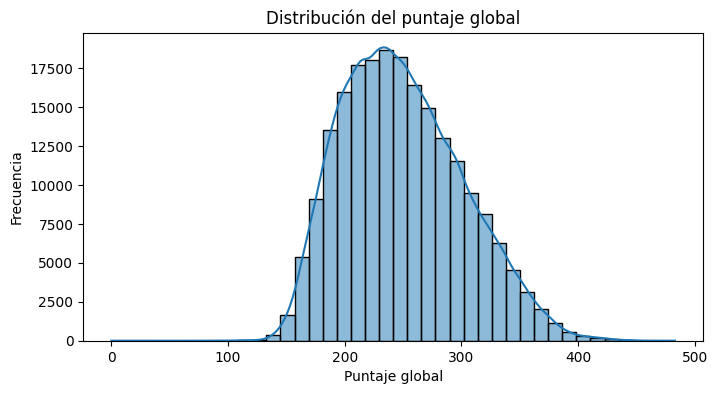

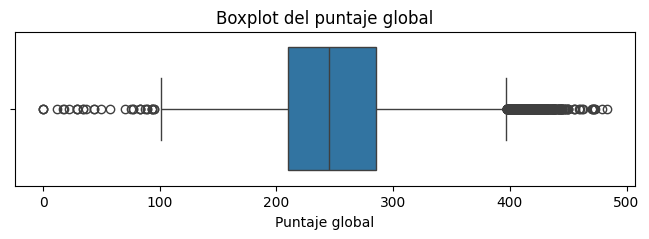

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df["punt_global"], bins=40, kde=True)
plt.title("Distribución del puntaje global")
plt.xlabel("Puntaje global")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df["punt_global"])
plt.title("Boxplot del puntaje global")
plt.xlabel("Puntaje global")
plt.show()

In [28]:
#Revisar si hay puntajes globales en 0
n_cero = (df["punt_global"] == 0).sum()
pct_cero = (df["punt_global"] == 0).mean() * 100

print("Registros con punt_global = 0:", n_cero)
print("Porcentaje:", round(pct_cero, 4), "%")

Registros con punt_global = 0: 3
Porcentaje: 0.0014 %


Como el porcentaje de valores en 0 es del 0.0014% se decide eliminarlos

In [29]:
df = df[df["punt_global"] > 0].copy()

Correlación con puntaje global

In [30]:
df.columns.tolist()

['periodo',
 'cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'punt_global',
 'cole_naturaleza_no oficial',
 'cole_bilingue_s',
 'cole_jornada_completa',
 'cole_jornada_noche',
 'cole_jornada_sabatina',
 'cole_jornada_tarde',
 'cole_jornada_unica',
 'cole_calendario_b',
 'cole_calendario_otro',
 'cole_area_ubicacion_rural',
 'cole_caracter_no aplica',
 'cole_caracter_técnico',
 'cole_caracter_técnico/académico',
 'cole_genero_femenino',
 'cole_genero_masculino',
 'fami_estratovivienda_estrato 2',
 'fami_estratovivienda_estrato 3',
 'fami_estratovivienda_estrato 4',
 'fami_estratovivienda_estrato 5',
 'fami_estratovivienda_estrato 6',
 'fami_estratovivienda_sin estrato',
 'fami_estratovivienda_sin_informacion',
 'fami_educacionmadre_educación profesional completa',
 'fami_educacionmadre_educación profesional incompleta',
 'fami_educacionmadre_ninguno',
 'fami_educacionmadre_no aplica',
 'fami_educacionmadre_no sabe'

In [31]:
score_col = "punt_global"

features = [c for c in df.columns if c != score_col]

corr = df[features + [score_col]].corr(numeric_only=True)[score_col]
corr = corr.drop(score_col).sort_values(key=abs, ascending=False)

corr.head(30)

cole_jornada_completa                                       0.349189
fami_tieneinternet_si                                       0.304775
cole_jornada_noche                                         -0.279357
fami_tienecomputador_si                                     0.279296
fami_tieneinternet_no                                      -0.270415
fami_tienecomputador_no                                    -0.265336
fami_educacionmadre_educación profesional completa          0.250232
fami_tieneautomovil_si                                      0.246049
fami_educacionpadre_educación profesional completa          0.238498
cole_calendario_b                                           0.227730
edad_presentacion                                          -0.211401
cole_naturaleza_no oficial                                  0.207841
cole_bilingue_s                                             0.206426
fami_educacionpadre_postgrado                               0.200812
fami_educacionmadre_postgrado     

Gráfica

C:\Users\maria\AppData\Local\Temp\ipykernel_25936\49009096.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


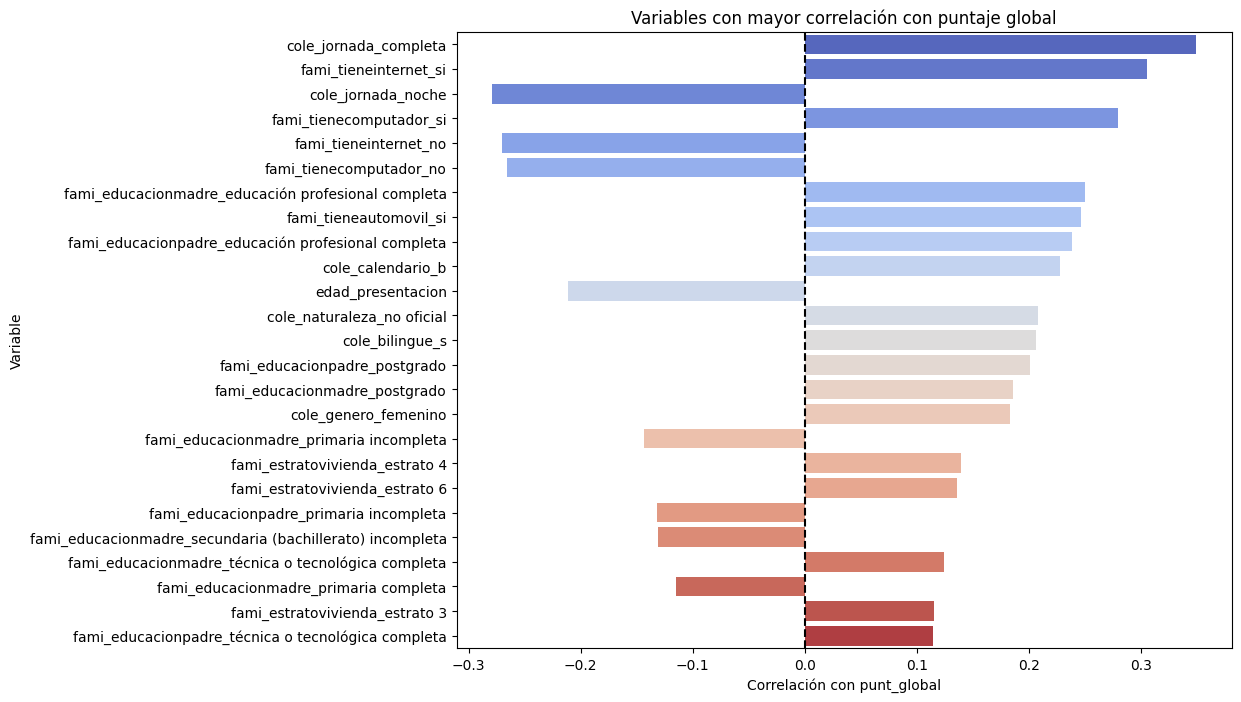

In [32]:
corr_top = corr.head(25).reset_index()
corr_top.columns = ["variable", "correlacion"]

plt.figure(figsize=(10,8))
sns.barplot(
    data=corr_top,
    x="correlacion",
    y="variable",
    palette="coolwarm"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Variables con mayor correlación con puntaje global")
plt.xlabel("Correlación con punt_global")
plt.ylabel("Variable")
plt.show()

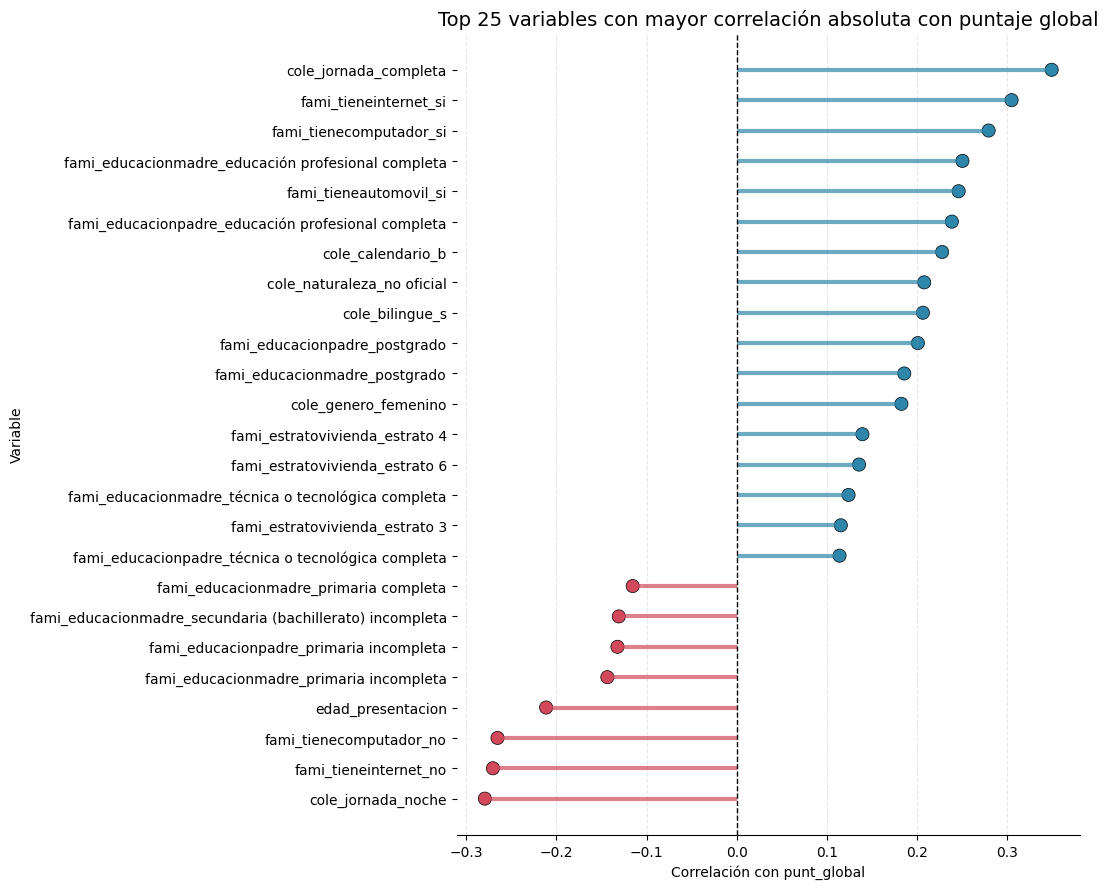

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tomar top 25 variables por correlación absoluta
corr_top = corr.reindex(corr.abs().sort_values(ascending=False).head(25).index).reset_index()
corr_top.columns = ["variable", "correlacion"]

# Ordenar para que se vea bien
corr_top = corr_top.sort_values("correlacion")

# Crear color según signo
colors = corr_top["correlacion"].apply(lambda x: "#2E86AB" if x > 0 else "#D1495B")

plt.figure(figsize=(11, 9))

# Líneas desde 0 hasta la correlación
plt.hlines(
    y=corr_top["variable"],
    xmin=0,
    xmax=corr_top["correlacion"],
    color=colors,
    alpha=0.7,
    linewidth=3
)

# Puntos finales
plt.scatter(
    corr_top["correlacion"],
    corr_top["variable"],
    color=colors,
    s=90,
    edgecolor="black",
    linewidth=0.5
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.title("Top 25 variables con mayor correlación absoluta con puntaje global", fontsize=14)
plt.xlabel("Correlación con punt_global")
plt.ylabel("Variable")

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

Variables institucionales como cole_jornada_completa, cole_jornada_noche, cole_calendario_b, cole_naturaleza_no oficial y cole_bilingue_s tienen asociaciones importantes con el puntaje global.
Variables familiares/socioeconómicas como fami_tieneinternet_si, fami_tienecomputador_si, educación profesional de madre/padre, automóvil y estrato también aparecen entre las más relacionadas.
edad_presentacion tiene correlación negativa, lo que sugiere que, en promedio, mayores edades al presentar la prueba se asocian con menor puntaje global.
Las variables fami_tieneinternet_no y fami_tienecomputador_no aparecen con correlación negativa, lo cual es coherente con que la ausencia de recursos tecnológicos se asocie con menores puntajes.

Diferencia de medias por variable dummy

In [34]:
score_col = "punt_global"

features = [c for c in df.columns if c != score_col]

relacion_dummy = []

for c in features:
    if df[c].nunique(dropna=True) == 2:
        media_0 = df.loc[df[c] == 0, score_col].mean()
        media_1 = df.loc[df[c] == 1, score_col].mean()
        n_0 = (df[c] == 0).sum()
        n_1 = (df[c] == 1).sum()

        relacion_dummy.append({
            "variable": c,
            "n_0": n_0,
            "n_1": n_1,
            "media_puntaje_0": media_0,
            "media_puntaje_1": media_1,
            "diferencia_media_1_menos_0": media_1 - media_0,
            "diferencia_abs": abs(media_1 - media_0)
        })

relacion_dummy = pd.DataFrame(relacion_dummy).sort_values(
    "diferencia_abs",
    ascending=False
)

relacion_dummy.head(30)

,variable,n_0,n_1,media_puntaje_0,media_puntaje_1,diferencia_media_1_menos_0,diferencia_abs
8,cole_calendario_b,206624,4068,247.986667,333.593412,85.606745,85.606745
2,cole_bilingue_s,207089,3603,248.231099,330.592562,82.361463,82.361463
40,fami_educacionpadre_postgrado,206053,4639,248.080945,318.868722,70.787777,70.787777
28,fami_educacionmadre_postgrado,205969,4723,248.184576,313.090409,64.905832,64.905832
20,fami_estratovivienda_estrato 6,207438,3254,248.761090,305.639828,56.878738,56.878738
3,cole_jornada_completa,181681,29011,242.421695,294.841233,52.419537,52.419537
4,cole_jornada_noche,190954,19738,254.285430,204.693231,-49.592199,49.592199
5,cole_jornada_sabatina,209349,1343,249.894984,209.821296,-40.073688,40.073688
21,fami_estratovivienda_sin estrato,207259,3433,250.265952,211.821730,-38.444222,38.444222
23,fami_educacionmadre_educación profesional comp...,182181,28511,244.518978,282.359195,37.840216,37.840216


C:\Users\maria\AppData\Local\Temp\ipykernel_25936\2604196356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


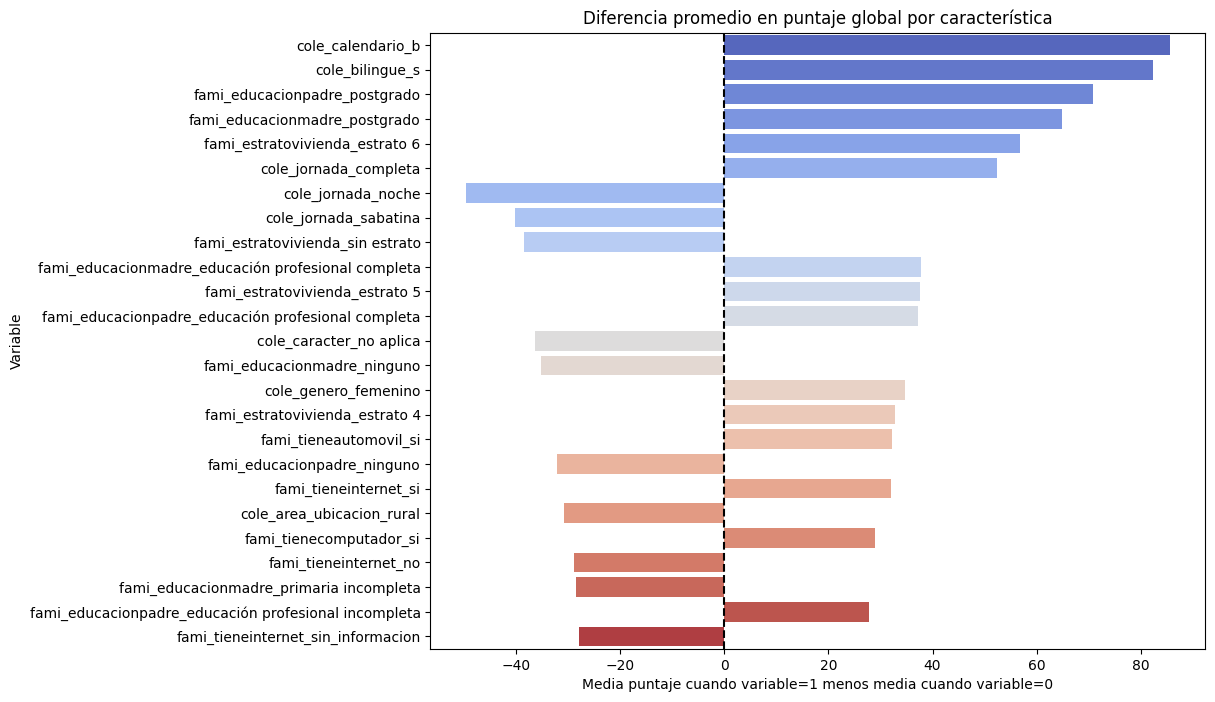

In [35]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=relacion_dummy.head(25),
    x="diferencia_media_1_menos_0",
    y="variable",
    palette="coolwarm"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Diferencia promedio en puntaje global por característica")
plt.xlabel("Media puntaje cuando variable=1 menos media cuando variable=0")
plt.ylabel("Variable")
plt.show()

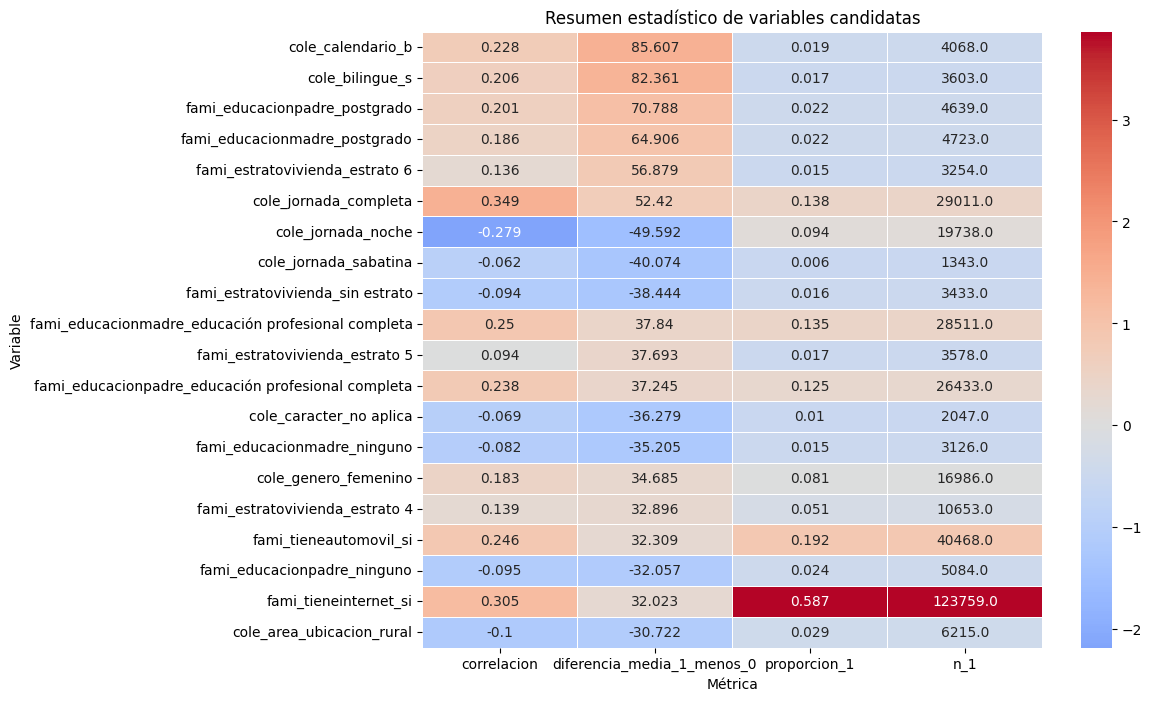

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supongo que ya tienes estas dos tablas:
# relacion_dummy
# corr

# Construir proporción de la categoría 1
resumen_vars = relacion_dummy.copy()
resumen_vars["correlacion"] = resumen_vars["variable"].map(corr)
resumen_vars["proporcion_1"] = resumen_vars["n_1"] / (resumen_vars["n_0"] + resumen_vars["n_1"])

# Quedarnos con las top 20 por diferencia absoluta
top_vars = resumen_vars.sort_values("diferencia_abs", ascending=False).head(20).copy()

# Seleccionar columnas para el heatmap
heatmap_df = top_vars[
    ["variable", "correlacion", "diferencia_media_1_menos_0", "proporcion_1", "n_1"]
].set_index("variable")

# Estandarizar solo para que las escalas sean comparables visualmente
heatmap_std = (heatmap_df - heatmap_df.mean()) / heatmap_df.std()

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_std,
    cmap="coolwarm",
    center=0,
    annot=heatmap_df.round(3),
    fmt="",
    linewidths=0.5
)
plt.title("Resumen estadístico de variables candidatas")
plt.xlabel("Métrica")
plt.ylabel("Variable")
plt.show()

## Análisis descriptivo: diferencia promedio en puntaje global por característica

Para identificar variables candidatas para el modelo de predicción del `punt_global`, se calculó la diferencia entre el puntaje promedio de los estudiantes que presentan cada característica (`variable = 1`) y el puntaje promedio de quienes no la presentan (`variable = 0`). Esta medida permite observar qué variables generan mayores diferencias descriptivas en el desempeño global.

La diferencia se interpreta así:

- Si la diferencia es **positiva**, los estudiantes con esa característica tienen, en promedio, un mayor puntaje global.
- Si la diferencia es **negativa**, los estudiantes con esa característica tienen, en promedio, un menor puntaje global.
- Mientras mayor sea la diferencia absoluta, mayor es la separación descriptiva entre los grupos.

### Variables asociadas con mayor puntaje global

Las variables con mayores diferencias positivas fueron principalmente institucionales y socioeconómicas. La característica con mayor diferencia fue `cole_calendario_b`, donde los estudiantes pertenecientes a colegios de calendario B presentan en promedio **85,61 puntos más** que los estudiantes que no pertenecen a esta categoría. Sin embargo, esta variable debe analizarse con cuidado porque solo cuenta con **4.068 registros** en la categoría positiva, lo cual representa una proporción pequeña frente al total de la base.

También se observa una diferencia alta en `cole_bilingue_s`, con una diferencia promedio de **82,36 puntos**. Esto sugiere que estudiar en un colegio bilingüe está asociado con puntajes globales más altos. Sin embargo, al igual que calendario B, esta categoría tiene una frecuencia relativamente baja, con **3.603 registros**, por lo que debe revisarse su estabilidad antes de usarla como variable principal del modelo.

En las variables familiares y socioeconómicas, destacan los niveles educativos altos de los padres. La variable `fami_educacionpadre_postgrado` presenta una diferencia promedio de **70,79 puntos**, mientras que `fami_educacionmadre_postgrado` presenta una diferencia de **64,91 puntos**. Esto indica que los estudiantes cuyos padres o madres tienen formación de posgrado tienden a obtener puntajes globales considerablemente mayores.

También aparecen variables asociadas a mayor nivel socioeconómico, como `fami_estratovivienda_estrato 6`, con una diferencia de **56,88 puntos**, y `fami_estratovivienda_estrato 5`, con **37,69 puntos**. Esto sugiere que el estrato de vivienda tiene una relación descriptiva importante con el puntaje global.

Otras variables relevantes son `cole_jornada_completa`, con una diferencia positiva de **52,42 puntos**, `fami_tieneautomovil_si`, con **32,31 puntos**, `fami_tieneinternet_si`, con **32,02 puntos**, y `fami_tienecomputador_si`, con **28,95 puntos**. Estas variables reflejan tanto condiciones institucionales como acceso a recursos del hogar.

### Variables asociadas con menor puntaje global

Algunas características presentan diferencias negativas importantes. La variable `cole_jornada_noche` muestra una diferencia de **-49,59 puntos**, lo que indica que los estudiantes de jornada nocturna tienen un puntaje global promedio considerablemente menor que los demás. De forma similar, `cole_jornada_sabatina` presenta una diferencia de **-40,07 puntos**.

La variable `fami_estratovivienda_sin estrato` tiene una diferencia de **-38,44 puntos**, lo cual sugiere que la ausencia de estrato reportado o la pertenencia a esta categoría está asociada con menores puntajes globales. También se observa una diferencia negativa en `cole_caracter_no aplica`, con **-36,28 puntos**.

En cuanto a educación de los padres, las categorías de menor nivel educativo presentan diferencias negativas. Por ejemplo, `fami_educacionmadre_ninguno` tiene una diferencia de **-35,21 puntos**, mientras que `fami_educacionpadre_ninguno` presenta una diferencia de **-32,06 puntos**. También se observan diferencias negativas en primaria incompleta de la madre y en categorías de información faltante.

Respecto al acceso a recursos tecnológicos, `fami_tieneinternet_no` tiene una diferencia de **-28,88 puntos**, mientras que `fami_tienecomputador_no` tiene una diferencia de **-27,63 puntos**. Esto refuerza la idea de que el acceso a internet y computador en el hogar está asociado con mejores resultados en Saber 11.

### Variables con categorías de baja frecuencia

Aunque algunas variables presentan diferencias muy altas, es importante considerar el número de registros en la categoría positiva. Por ejemplo, `cole_calendario_b`, `cole_bilingue_s`, `fami_educacionpadre_postgrado`, `fami_educacionmadre_postgrado` y `fami_estratovivienda_estrato 6` tienen diferencias promedio elevadas, pero sus categorías positivas representan una proporción relativamente pequeña de la base.

Por esta razón, estas variables pueden ser útiles para el modelo, pero deben revisarse junto con su frecuencia. Una diferencia alta en una categoría poco frecuente puede ser menos estable que una diferencia moderada en una categoría con muchos registros.

### Interpretación general

El análisis muestra que el puntaje global está asociado tanto con características institucionales como con condiciones familiares y socioeconómicas. En particular, las variables más relevantes descriptivamente se agrupan en cuatro dimensiones:

1. **Características institucionales del colegio**, como calendario, bilingüismo, jornada y carácter.
2. **Nivel educativo de los padres**, especialmente educación profesional y posgrado.
3. **Condiciones socioeconómicas del hogar**, como estrato, automóvil, computador e internet.
4. **Condiciones asociadas a menor desempeño**, como jornada nocturna, jornada sabatina, ausencia de internet, ausencia de computador y bajos niveles educativos de los padres.

Estos resultados sugieren que el modelo predictivo debería incluir variables de estos grupos, siempre que tengan suficiente frecuencia y estén alineadas con la pregunta de negocio.

### Variables candidatas para el modelo

A partir de este análisis descriptivo, se pueden considerar como variables candidatas iniciales:
 
- "edad_presentacion"
- "cole_jornada"
- "cole_calendario",
- "cole_bilingue",
- "cole_naturaleza",
- "fami_tieneinternet",
- "fami_tienecomputador",
- "fami_educacionmadre",
- "fami_educacionpadre",
- "fami_estratovivienda",
- "fami_tieneautomovil"

In [37]:
df.head(20)

,periodo,cole_mcpio_ubicacion,cole_sede_principal,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,punt_global,cole_naturaleza_no oficial,cole_bilingue_s,cole_jornada_completa,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_b,cole_calendario_otro,cole_area_ubicacion_rural,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin estrato,fami_estratovivienda_sin_informacion,fami_educacionmadre_educación profesional completa,fami_educacionmadre_educación profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_técnica o tecnológica completa,fami_educacionmadre_técnica o tecnológica incompleta,fami_educacionpadre_educación profesional completa,fami_educacionpadre_educación profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_técnica o tecnológica completa,fami_educacionpadre_técnica o tecnológica incompleta,fami_personashogar_1 a 2,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o más,fami_personashogar_cinco,fami_personashogar_cuatro,fami_personashogar_diez,fami_personashogar_doce o más,fami_personashogar_dos,fami_personashogar_nueve,fami_personashogar_ocho,fami_personashogar_once,fami_personashogar_seis,fami_personashogar_siete,fami_personashogar_sin_informacion,fami_personashogar_tres,fami_personashogar_una,fami_cuartoshogar_cinco,fami_cuartoshogar_cuatro,fami_cuartoshogar_diez o más,fami_cuartoshogar_dos,fami_cuartoshogar_nueve,fami_cuartoshogar_ocho,fami_cuartoshogar_seis,fami_cuartoshogar_seis o mas,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_uno,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_sin_informacion,edad_presentacion,edad_invalida_original,fami_tienecomputador_no,fami_tienecomputador_si,fami_tienecomputador_sin_informacion,fami_tieneinternet_no,fami_tieneinternet_si,fami_tieneinternet_sin_informacion,estu_genero_m,estu_genero_sin_informacion
0,20194,BARRANQUILLA,S,MALAMBO,BARRANQUILLA,COLOMBIA,286.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,27.0,0,True,False,False,False,True,False,0,0
1,20194,BARRANQUILLA,S,MALAMBO,BARRANQUILLA,COLOMBIA,286.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,27.0,0,True,False,False,False,True,False,0,0
2,20142,SABANALARGA,S,SABANALARGA,SABANALARGA,COLOMBIA,223.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,16.0,0,True,False,False,True,False,False,1,0
3,20162,SOLEDAD,S,SOLEDAD,SOLEDAD,COLOMBIA,274.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17.0,0,False,True,False,False,True,False,1,0
4,20142,BARRANQUILLA,S,BARRANQUILLA,BARRANQUILLA,COLOMBIA,266.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,16.0,

In [38]:
drop_cols = [

"punt_global",

# geográficas / administrativas
"periodo",
"cole_mcpio_ubicacion",
"estu_mcpio_presentacion",
"estu_mcpio_reside",
"estu_nacionalidad",

# variables auxiliares
"edad_invalida_original"
]

X = df.drop(columns=drop_cols)

## Desarrollo Del Modelo

## Modelo 1

In [39]:
selected_cols = [

    "punt_global",
    "edad_presentacion",

    # jornada
    *[c for c in df.columns if c.startswith("cole_jornada")],

    # calendario
    *[c for c in df.columns if c.startswith("cole_calendario")],

    # bilingue
    *[c for c in df.columns if c.startswith("cole_bilingue")],

    # naturaleza
    *[c for c in df.columns if c.startswith("cole_naturaleza")],

    # internet
    *[c for c in df.columns if c.startswith("fami_tieneinternet")],

    # computador
    *[c for c in df.columns if c.startswith("fami_tienecomputador")],

    # educación madre
    *[c for c in df.columns if c.startswith("fami_educacionmadre")],

    # educación padre
    *[c for c in df.columns if c.startswith("fami_educacionpadre")],

    # estrato
    *[c for c in df.columns if c.startswith("fami_estratovivienda")],

    # automóvil
    *[c for c in df.columns if c.startswith("fami_tieneautomovil")]
]

df = df[selected_cols]


In [40]:
df.head()

,punt_global,edad_presentacion,cole_jornada_completa,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_b,cole_calendario_otro,cole_bilingue_s,cole_naturaleza_no oficial,fami_tieneinternet_no,fami_tieneinternet_si,fami_tieneinternet_sin_informacion,fami_tienecomputador_no,fami_tienecomputador_si,fami_tienecomputador_sin_informacion,fami_educacionmadre_educación profesional completa,fami_educacionmadre_educación profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_técnica o tecnológica completa,fami_educacionmadre_técnica o tecnológica incompleta,fami_educacionpadre_educación profesional completa,fami_educacionpadre_educación profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_técnica o tecnológica completa,fami_educacionpadre_técnica o tecnológica incompleta,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin estrato,fami_estratovivienda_sin_informacion,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion
0,286.0,27.0,0,0,0,0,0,0,0,0,1,False,True,False,True,False,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,286.0,27.0,0,0,0,0,0,0,0,0,1,False,True,False,True,False,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,223.0,16.0,0,0,0,0,0,0,0,0,0,True,False,False,True,False,False,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,274.0,17.0,0,0,0,0,0,0,0,0,0,False,True,False,False,True,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
4,266.0,16.0,0,0,0,1,0,0,0,0,0,True,False,False,True,False,False,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0


In [41]:
#Para dash hay que guardar el orden de las columnas
model_columns = df.columns.tolist()
import joblib
joblib.dump(model_columns, "model_columns.pkl")

['model_columns.pkl']

In [42]:
X = df.drop(columns=["punt_global"])
y = df["punt_global"]

In [43]:
X.dtypes.value_counts()

int64      42
bool        6
float64     1
Name: count, dtype: int64

In [44]:
#Pasar todo a float para evitar problemas con el modelo
X = X.astype(float)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(168553, 49)
(42139, 49)


In [46]:
import numpy as np
from tensorflow.keras.layers import Normalization

normalizer = Normalization()

normalizer.adapt(
    np.array(X_train)
)

In [47]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

model = keras.Sequential([

    normalizer,

    layers.Dense(
        32,
        activation='relu'
    ),

    layers.Dense(1)
])

In [49]:
model.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 49)                99        
 on)                                                             
                                                                 
 dense (Dense)               (None, 32)                1600      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1732 (6.77 KB)
Trainable params: 1633 (6.38 KB)
Non-trainable params: 99 (400.00 Byte)
_________________________________________________________________


In [50]:
early_stop = keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [51]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=200,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/200


4214/4214 [==============================] - 10s 2ms/step - loss: 12386.8467 - mae: 80.2231 - val_loss: 2334.6978 - val_mae: 38.0421
Epoch 2/200
4214/4214 [==============================] - 9s 2ms/step - loss: 2053.1841 - mae: 35.8245 - val_loss: 1953.1698 - val_mae: 35.1033
Epoch 3/200
4214/4214 [==============================] - 8s 2ms/step - loss: 1892.6980 - mae: 34.6079 - val_loss: 1876.1904 - val_mae: 34.6098
Epoch 4/200
4214/4214 [==============================] - 8s 2ms/step - loss: 1836.9213 - mae: 34.2101 - val_loss: 1835.7439 - val_mae: 34.2656
Epoch 5/200
4214/4214 [==============================] - 8s 2ms/step - loss: 1803.6516 - mae: 33.9704 - val_loss: 1810.7565 - val_mae: 34.1099
Epoch 6/200
4214/4214 [==============================] - 8s 2ms/step - loss: 1782.4650 - mae: 33.8050 - val_loss: 1790.9633 - val_mae: 33.8784
Epoch 7/200
4214/4214 [==============================] - 8s 2ms/step - loss: 1768.9493 - mae: 33.6957 - val_loss: 1781.3077 - val_mae: 33.

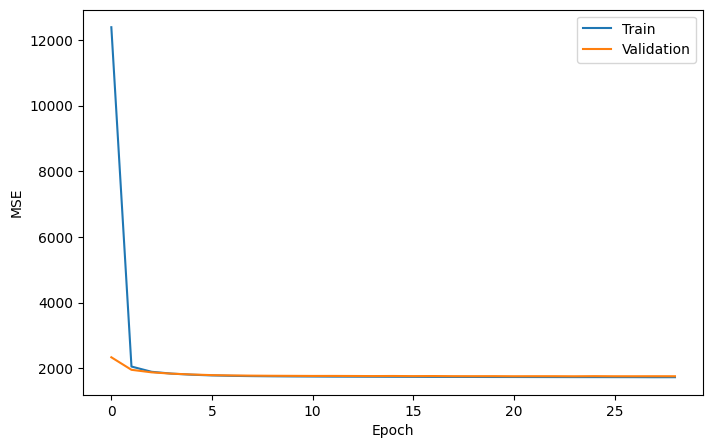

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [53]:
pred = model.predict(X_test)

1317/1317 [==============================] - 2s 1ms/step


In [54]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

mae = mean_absolute_error(
    y_test,
    pred
)
r2 = r2_score(
    y_test,
    pred
)

print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)

RMSE: 41.856591534528185
MAE: 33.64280979613925
R2: 0.34505575066219163


## Modelo 2 - mejora sobre el modelo 1

In [ ]:
X = df.drop(columns=["punt_global"])
y = df["punt_global"]

X.dtypes.value_counts()

#Pasar todo a float para evitar problemas con el modelo
X = X.astype(float)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

import numpy as np
from tensorflow.keras.layers import Normalization

normalizer = Normalization()

normalizer.adapt(
    np.array(X_train)
)


In [55]:
import mlflow
import mlflow.keras

neurons1 = 64
neurons2 = 32
drop = 0.2

experiment = mlflow.set_experiment(
    "saber11_regresion_atlantico"
)

with mlflow.start_run():

    mlflow.keras.autolog()

    normalizer = layers.Normalization()
    normalizer.adapt(np.array(X_train))

    model2 = keras.Sequential([

        normalizer,

        layers.Dense(
            neurons1,
            activation='relu'
        ),

        layers.Dropout(drop),

        layers.Dense(
            neurons2,
            activation='relu'
        ),

        layers.Dense(1)
    ])

    model2.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history2 = model2.fit(

        X_train,
        y_train,

        validation_split=.2,

        epochs=100,

        batch_size=32,

        callbacks=[early_stop],

        verbose=1
    )

    pred2 = model2.predict(X_test).flatten()

    mse2 = mean_squared_error(y_test,pred2)
    rmse2 = np.sqrt(mse2)
    mae2 = mean_absolute_error(y_test,pred2)
    r22 = r2_score(y_test,pred2)

    mlflow.log_metric("rmse", rmse2)
    mlflow.log_metric("mae", mae2)
    mlflow.log_metric("r2", r22)

    print(rmse2, mae2, r22)

2026/05/22 13:43:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/22 13:43:04 INFO mlflow.store.db.utils: Updating database tables
2026/05/22 13:43:06 INFO mlflow.tracking.fluent: Experiment with name 'saber11_regresion_atlantico' does not exist. Creating a new experiment.
2026/05/22 13:43:06 WARNING mlflow.utils.autologging_utils: MLflow tensorflow autologging is known to be compatible with 2.16.2 <= tensorflow, but the installed version is 2.15.0. If you encounter errors during autologging, try upgrading / downgrading tensorflow to a compatible version, or try upgrading MLflow.
2026/05/22 13:43:12 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.


Epoch 1/100
4214/4214 [==============================] - 14s 3ms/step - loss: 4585.3247 - mae: 47.4952 - val_loss: 1814.2125 - val_mae: 34.0661
Epoch 2/100
  39/4214 [..............................] - ETA: 11s - loss: 2153.2349 - mae: 36.8676

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4214/4214 [==============================] - 12s 3ms/step - loss: 2187.7642 - mae: 37.3172 - val_loss: 1864.1028 - val_mae: 34.2788
Epoch 3/100
4214/4214 [==============================] - 12s 3ms/step - loss: 2099.6853 - mae: 36.5673 - val_loss: 1778.6393 - val_mae: 33.7250
Epoch 4/100
4214/4214 [==============================] - 13s 3ms/step - loss: 2026.1614 - mae: 35.9391 - val_loss: 1772.7211 - val_mae: 33.6959
Epoch 5/100
4214/4214 [==============================] - 12s 3ms/step - loss: 1971.8506 - mae: 35.4436 - val_loss: 1767.3621 - val_mae: 33.7176
Epoch 6/100
4214/4214 [==============================] - 13s 3ms/step - loss: 1926.0280 - mae: 35.0580 - val_loss: 1827.4586 - val_mae: 33.9355
Epoch 7/100
4214/4214 [==============================] - 13s 3ms/step - loss: 1892.4491 - mae: 34.7909 - val_loss: 1758.2523 - val_mae: 33.6742
Epoch 8/100
4214/4214 [==============================] - 12s 3ms/step - loss: 1866.3134 - mae: 34.5746 - val_loss: 1759.4998 - val_mae: 33.6623
Epoc

2026/05/22 13:45:43 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2026/05/22 13:45:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 13:45:43 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: C:\Users\maria\AppData\Local\Temp\tmppg7ubbof\model\data\model\assets


INFO:tensorflow:Assets written to: C:\Users\maria\AppData\Local\Temp\tmppg7ubbof\model\data\model\assets


1317/1317 [==============================] - 3s 2ms/step
41.97313802372477 33.703819845219456 0.34140338817236093


Este modelo no mejora significativamente frente al modelo 1. R2 casi igual, en modelo 1 fue 0.345 y en modelo 2 fue 0.341

## Modelo 3 - Sin dropout

In [ ]:
X = df.drop(columns=["punt_global"])
y = df["punt_global"]

X.dtypes.value_counts()

#Pasar todo a float para evitar problemas con el modelo
X = X.astype(float)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

import numpy as np
from tensorflow.keras.layers import Normalization

normalizer = Normalization()

normalizer.adapt(
    np.array(X_train)
)


In [58]:
import numpy as np
import mlflow
import mlflow.keras

from tensorflow import keras
from keras import layers

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# MLflow server local
mlflow.set_tracking_uri(
    "http://localhost:5000"
)

# experimento
experiment = mlflow.set_experiment(
    "saber11_regresion_atlantico"
)

# numpy para MLflow
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

# hiperparámetros
neurons1 = 64
neurons2 = 32
activation = "relu"
optimizer = "adam"
epochs = 100
batch_size = 32
patience = 5

tf.keras.utils.set_random_seed(42)

with mlflow.start_run(
    experiment_id=experiment.experiment_id
):

    # autolog keras
    mlflow.keras.autolog()

    # normalización
    normalizer = layers.Normalization()
    normalizer.adapt(X_train_np)

    # modelo
    model3 = keras.Sequential([

        normalizer,

        layers.Dense(
            neurons1,
            activation=activation
        ),

        layers.Dense(
            neurons2,
            activation=activation
        ),

        layers.Dense(1)
    ])

    model3.compile(

        optimizer=optimizer,

        loss="mse",

        metrics=["mae"]
    )

    # early stopping
    early_stop = keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=patience,

        restore_best_weights=True
    )

    # entrenamiento
    history3 = model3.fit(

        X_train_np,
        y_train,

        validation_split=0.2,

        epochs=epochs,

        batch_size=batch_size,

        callbacks=[early_stop],

        verbose=1
    )

    # predicción
    pred3 = model3.predict(
        X_test_np
    ).flatten()

    # métricas
    mse3 = mean_squared_error(
        y_test,
        pred3
    )

    rmse3 = np.sqrt(mse3)

    mae3 = mean_absolute_error(
        y_test,
        pred3
    )

    r23 = r2_score(
        y_test,
        pred3
    )

    # registrar parámetros
    mlflow.log_param(
        "neurons_1",
        neurons1
    )

    mlflow.log_param(
        "neurons_2",
        neurons2
    )

    mlflow.log_param(
        "activation",
        activation
    )

    mlflow.log_param(
        "optimizer",
        optimizer
    )

    mlflow.log_param(
        "epochs",
        epochs
    )

    mlflow.log_param(
        "batch_size",
        batch_size
    )

    mlflow.log_param(
        "patience",
        patience
    )

    # registrar modelo
    mlflow.keras.log_model(
        model3,
        "keras-model"
    )

    # registrar métricas
    mlflow.log_metric(
        "mse",
        mse3
    )

    mlflow.log_metric(
        "rmse",
        rmse3
    )

    mlflow.log_metric(
        "mae",
        mae3
    )

    mlflow.log_metric(
        "r2",
        r23
    )

    print("RMSE:", rmse3)
    print("MAE:", mae3)
    print("R2:", r23)

2026/05/22 14:05:35 WARNING mlflow.utils.autologging_utils: MLflow tensorflow autologging is known to be compatible with 2.16.2 <= tensorflow, but the installed version is 2.15.0. If you encounter errors during autologging, try upgrading / downgrading tensorflow to a compatible version, or try upgrading MLflow.
2026/05/22 14:05:45 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Epoch 1/100
   1/4214 [..............................] - ETA: 1:36:54 - loss: 62557.1211 - mae: 246.9601WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0018s vs `on_train_batch_end` time: 0.0043s). Check your callbacks.


4211/4214 [============================>.] - ETA: 0s - loss: 4311.9277 - mae: 44.3748

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4214/4214 [==============================] - 21s 5ms/step - loss: 4310.2534 - mae: 44.3677 - val_loss: 1822.2966 - val_mae: 34.1902
Epoch 2/100
4214/4214 [==============================] - 18s 4ms/step - loss: 1785.1382 - mae: 33.8523 - val_loss: 1780.1946 - val_mae: 33.6551
Epoch 3/100
4214/4214 [==============================] - 15s 3ms/step - loss: 1763.5020 - mae: 33.6553 - val_loss: 1770.7755 - val_mae: 33.7181
Epoch 4/100
4214/4214 [==============================] - 11s 3ms/step - loss: 1753.8412 - mae: 33.5632 - val_loss: 1781.0311 - val_mae: 33.7209
Epoch 5/100
4214/4214 [==============================] - 13s 3ms/step - loss: 1747.6074 - mae: 33.5147 - val_loss: 1764.1472 - val_mae: 33.5431
Epoch 6/100
4214/4214 [==============================] - 11s 3ms/step - loss: 1741.3300 - mae: 33.4277 - val_loss: 1769.6211 - val_mae: 33.6404
Epoch 7/100
4214/4214 [==============================] - 14s 3ms/step - loss: 1736.4253 - mae: 33.3793 - val_loss: 1756.4047 - val_mae: 33.5953
Epoc

...

1317/1317 [==============================] - 2s 1ms/step


2026/05/22 14:10:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 14:10:29 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: C:\Users\maria\AppData\Local\Temp\tmpu2mbl858\model\data\model\assets


INFO:tensorflow:Assets written to: C:\Users\maria\AppData\Local\Temp\tmpu2mbl858\model\data\model\assets


RMSE: 41.83398311957971
MAE: 33.59398274333542
R2: 0.3457630826173672
🏃 View run victorious-jay-820 at: http://localhost:5000/#/experiments/1/runs/dbb9abfe5b1045c28d002521dedcc423
🧪 View experiment at: http://localhost:5000/#/experiments/1
